Found 13 molecule notebooks:
 - beh2_fermionic.ipynb
 - c2_fermionic.ipynb
 - ch4_fermionic.ipynb
 - co_fermionic.ipynb
 - h10_fermionic.ipynb
 - h2_fermionic.ipynb
 - h2o_fermionic.ipynb
 - h4_fermionic.ipynb
 - h6_fermionic.ipynb
 - h8_fermionic.ipynb
 - lih_fermionic.ipynb
 - n2_fermionic.ipynb
 - nh3_fermionic.ipynb


,molecule,notebook,n_qubits,vertices,noncommuting_pairs,colors,JW_duplication_ratio
0,H2,h2_fermionic.ipynb,4,13,12,2,3.266667
1,H4,h4_fermionic.ipynb,8,111,3348,15,3.248649
2,H6,h6_fermionic.ipynb,12,499,73260,65,3.369967
3,LiH,lih_fermionic.ipynb,12,42,376,7,3.048387
4,BeH2,beh2_fermionic.ipynb,14,386,35170,45,3.304805
5,H2O,h2o_fermionic.ipynb,14,596,94390,63,3.275322
6,H8,h8_fermionic.ipynb,16,1525,639264,137,3.477171
7,NH3,nh3_fermionic.ipynb,16,1873,983776,199,3.416182
8,CH4,ch4_fermionic.ipynb,18,2413,1664330,262,3.451695
9,C2,c2_fermionic.ipynb,20,657,107184,53,3.705183


Saved: fermionic_metric_plots/colors_by_molecule.png


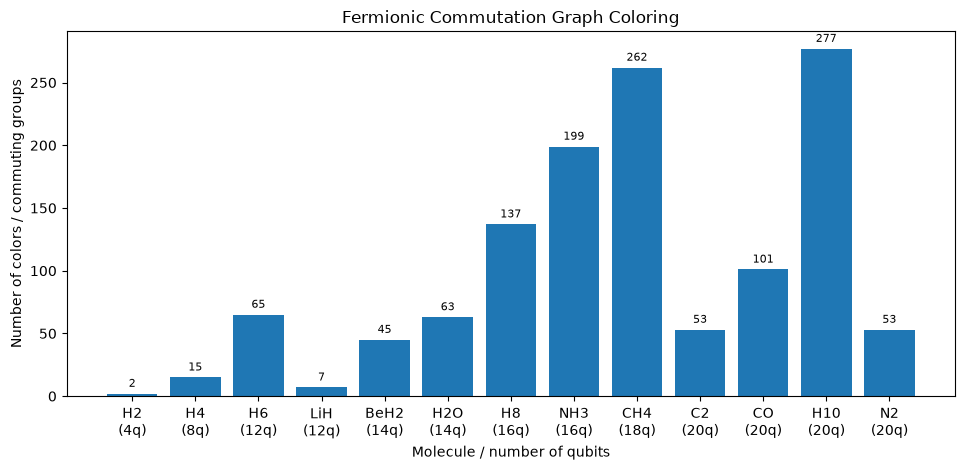

Saved: fermionic_metric_plots/vertices_by_molecule.png


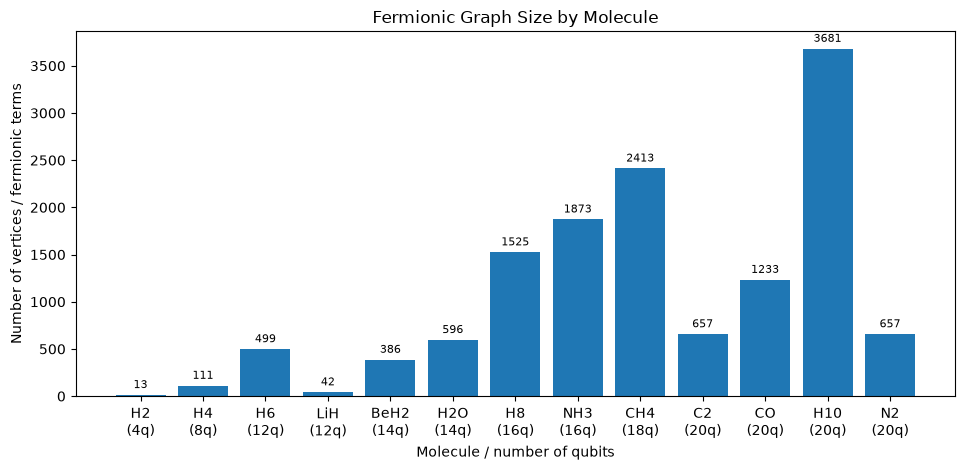

Saved: fermionic_metric_plots/jw_duplication_ratio_by_molecule.png


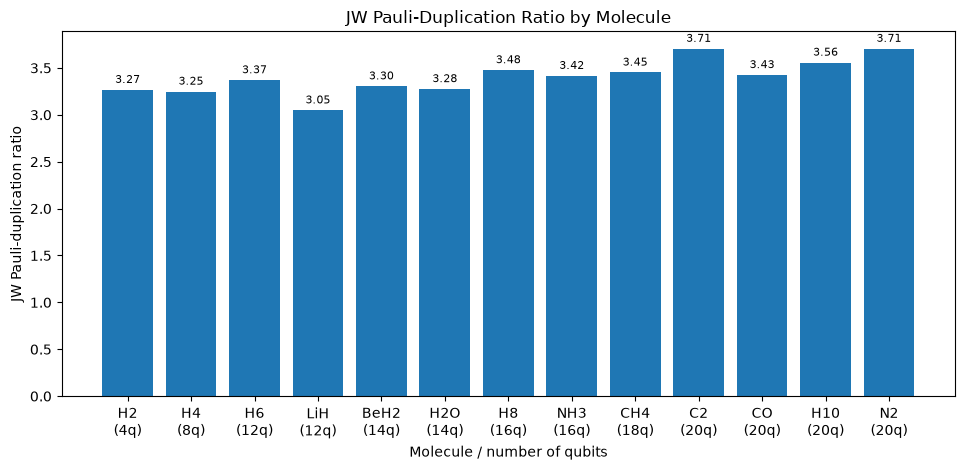

Saved: fermionic_metric_plots/noncommuting_pairs_by_molecule.png


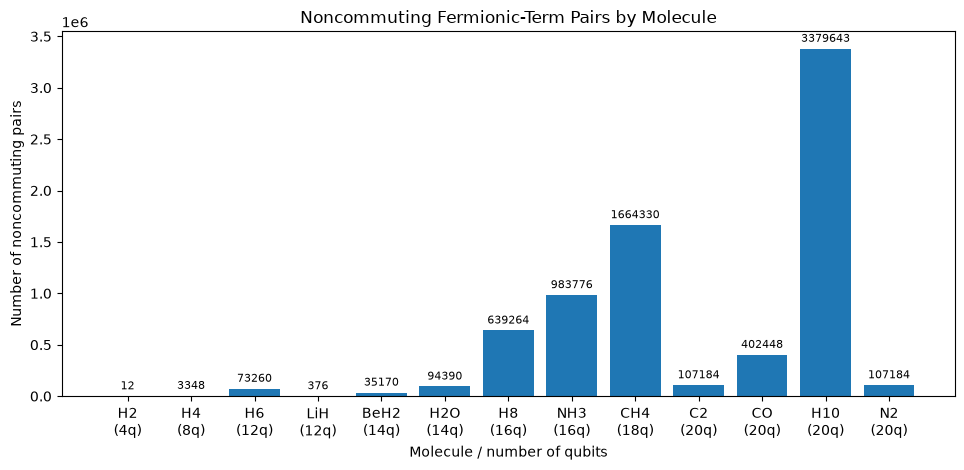

In [3]:
# ============================================================
# Compare fermionic noncommutation graph metrics across molecules
# Run this from the repository root on branch fermion_hamil.
# ============================================================

from pathlib import Path
import json
import re
import html

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
NOTEBOOK_DIR = Path(".")
NOTEBOOKS = sorted(
    path for path in NOTEBOOK_DIR.rglob("*_fermionic.ipynb")
    if ".ipynb_checkpoints" not in str(path)
)

# Choose which mapping duplication ratio to plot.
# Use "JW" or "BK".
DUPLICATION_MAPPING = "JW"

PLOT_DIR = Path("fermionic_metric_plots")
PLOT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def clean_output_text(text):
    """
    Clean notebook output text/html so regex extraction is easier.
    """
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text


def notebook_output_text(path):
    """
    Extract all visible code outputs from a Jupyter notebook.
    This assumes the molecule notebooks have already been run
    and contain printed outputs / displayed dataframes.
    """
    nb = json.loads(path.read_text())
    chunks = []

    for cell in nb.get("cells", []):
        for out in cell.get("outputs", []):
            if "text" in out:
                value = out["text"]
                if isinstance(value, list):
                    chunks.append("".join(value))
                else:
                    chunks.append(str(value))

            data = out.get("data", {})
            for key in ["text/plain", "text/html"]:
                if key in data:
                    value = data[key]
                    if isinstance(value, list):
                        chunks.append("".join(value))
                    else:
                        chunks.append(str(value))

    return clean_output_text("\n".join(chunks))


def first_int(text, patterns):
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        if match:
            return int(match.group(1))
    return None


def first_float(text, patterns):
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        if match:
            return float(match.group(1))
    return None


def molecule_name_from_path(path):
    """
    Fallback molecule name if the notebook output does not contain
    a printed 'Molecule: ...' line.
    """
    name = path.stem.replace("_fermionic", "")

    pretty_names = {
        "h2": "H2",
        "h4": "H4",
        "h6": "H6",
        "h8": "H8",
        "h10": "H10",
        "lih": "LiH",
        "beh2": "BeH2",
        "h2o": "H2O",
        "nh3": "NH3",
        "co": "CO",
        "c2": "C2",
        "n2": "N2",
    }

    return pretty_names.get(name.lower(), name.upper())


def extract_molecule_name(text, path):
    """
    Extract molecule name as a string.
    This fixes the earlier bug where the molecule name was accidentally
    parsed using first_int().
    """
    match = re.search(r"Molecule:\s*([A-Za-z0-9]+)", text, flags=re.IGNORECASE)
    if match:
        return match.group(1)

    return molecule_name_from_path(path)


def extract_duplication_ratio(text, mapping="JW"):
    """
    Extract duplication ratio from a printed dataframe row.

    Expected row format may look like:
    JW True 601 269 185 3.248649 2.234201

    We extract the first float after the first three integer count columns.
    """
    mapping = mapping.upper()

    patterns = [
        (
            rf"\b{mapping}\s+"
            rf"(?:True|False)\s+"
            rf"\d+\s+\d+\s+\d+\s+"
            rf"([0-9]+(?:\.[0-9]+)?)"
        ),
        (
            rf"\b{mapping}\b.*?"
            rf"duplication_ratio.*?"
            rf"([0-9]+(?:\.[0-9]+)?)"
        ),
    ]

    return first_float(text, patterns)


def extract_noncommuting_pairs(text):
    """
    Extract number of noncommuting pairs / graph edges.
    """
    explicit = first_int(
        text,
        [
            r"Number of noncommuting pairs / graph edges:\s*(\d+)",
            r"Number of noncommuting pairs / edges:\s*(\d+)",
            r"Number of noncommuting pairs:\s*(\d+)",
            r"Number of edges:\s*(\d+)",
        ],
    )

    if explicit is not None:
        return explicit

    table_match = re.search(
        r"noncommuting pairs.*?\[(\d+)\s+rows",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if table_match:
        return int(table_match.group(1))

    return None


def extract_metrics(path):
    text = notebook_output_text(path)

    molecule = extract_molecule_name(text, path)

    n_qubits = first_int(
        text,
        [
            r"Number of spin orbitals / fermionic modes:\s*(\d+)",
            r"Number of qubits / spin orbitals:\s*(\d+)",
            r"Number of qubits:\s*(\d+)",
            r"n_qubits\s*[:=]\s*(\d+)",
        ],
    )

    vertices = first_int(
        text,
        [
            r"Number of vertices / fermionic terms:\s*(\d+)",
            r"Number of fermionic terms / vertices:\s*(\d+)",
            r"Number of Hermitian fermionic terms:\s*(\d+)",
            r"Number of vertices:\s*(\d+)",
        ],
    )

    colors = first_int(
        text,
        [
            r"Number of colors / commuting groups:\s*(\d+)",
            r"Number of colors:\s*(\d+)",
            r"Greedy colors:\s*(\d+)",
        ],
    )

    noncommuting_pairs = extract_noncommuting_pairs(text)

    duplication_ratio = extract_duplication_ratio(
        text,
        mapping=DUPLICATION_MAPPING,
    )

    return {
        "molecule": molecule,
        "notebook": str(path),
        "n_qubits": n_qubits,
        "vertices": vertices,
        "noncommuting_pairs": noncommuting_pairs,
        "colors": colors,
        f"{DUPLICATION_MAPPING}_duplication_ratio": duplication_ratio,
    }


# ------------------------------------------------------------
# Build summary table
# ------------------------------------------------------------
print(f"Found {len(NOTEBOOKS)} molecule notebooks:")
for path in NOTEBOOKS:
    print(" -", path)

rows = [extract_metrics(path) for path in NOTEBOOKS]
summary_df = pd.DataFrame(rows)

summary_df = summary_df.sort_values(
    by=["n_qubits", "molecule"],
    na_position="last",
).reset_index(drop=True)

display(summary_df)

missing_cols = [
    "n_qubits",
    "vertices",
    "colors",
    f"{DUPLICATION_MAPPING}_duplication_ratio",
]

missing = summary_df[summary_df[missing_cols].isna().any(axis=1)]

if not missing.empty:
    print("\nSome notebooks are missing extracted values:")
    display(missing)


# ------------------------------------------------------------
# Plotting helper
# ------------------------------------------------------------
def make_bar_plot(df, y_col, ylabel, title, filename, integer_labels=True):
    plot_df = df.dropna(subset=["molecule", "n_qubits", y_col]).copy()

    if plot_df.empty:
        print(f"Skipping plot: no data found for {y_col}")
        return

    labels = [
        f"{mol}\n({int(q)}q)"
        for mol, q in zip(plot_df["molecule"], plot_df["n_qubits"])
    ]

    fig, ax = plt.subplots(figsize=(max(8, 0.75 * len(plot_df)), 4.8))

    bars = ax.bar(labels, plot_df[y_col])

    ax.set_xlabel("Molecule / number of qubits")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if integer_labels:
        ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=8)
    else:
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

    ax.tick_params(axis="x", labelrotation=0)

    fig.tight_layout()

    outpath = PLOT_DIR / filename
    fig.savefig(outpath, dpi=200, bbox_inches="tight")

    print(f"Saved: {outpath}")
    plt.show()


# ------------------------------------------------------------
# Three main bar graphs for the presentation
# ------------------------------------------------------------
make_bar_plot(
    summary_df,
    y_col="colors",
    ylabel="Number of colors / commuting groups",
    title="Fermionic Commutation Graph Coloring",
    filename="colors_by_molecule.png",
    integer_labels=True,
)

make_bar_plot(
    summary_df,
    y_col="vertices",
    ylabel="Number of vertices / fermionic terms",
    title="Fermionic Graph Size by Molecule",
    filename="vertices_by_molecule.png",
    integer_labels=True,
)

make_bar_plot(
    summary_df,
    y_col=f"{DUPLICATION_MAPPING}_duplication_ratio",
    ylabel=f"{DUPLICATION_MAPPING} Pauli-duplication ratio",
    title=f"{DUPLICATION_MAPPING} Pauli-Duplication Ratio by Molecule",
    filename=f"{DUPLICATION_MAPPING.lower()}_duplication_ratio_by_molecule.png",
    integer_labels=False,
)


# ------------------------------------------------------------
# Optional fourth graph: noncommuting pairs
# Useful if you want to show graph density growth.
# ------------------------------------------------------------
make_bar_plot(
    summary_df,
    y_col="noncommuting_pairs",
    ylabel="Number of noncommuting pairs",
    title="Noncommuting Fermionic-Term Pairs by Molecule",
    filename="noncommuting_pairs_by_molecule.png",
    integer_labels=True,
)